In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

In [2]:
mybl_lang = pd.read_csv('mybl_lang.csv')
mybl_lang = mybl_lang.loc[mybl_lang['name'] != 'Swift']
mybl_lang.drop('id', axis=1, inplace=True)

In [3]:
langs = mybl_lang.pivot(index='date_added', columns='name', values=['val', 'val_noexp', 'res_vac'])
langs.dropna(inplace=True)

In [4]:
Mind = pd.MultiIndex.from_tuples([('res', i) for i in langs['val'].columns])
langs_res = langs['res_vac'] * langs['val']
langs_res.columns = Mind
langs = pd.merge(langs, langs_res, how='left', on='date_added')

In [5]:
#normalization
for i in langs.columns:
    langs[i] = langs[i]/(max(langs[i]))

langs.describe()

val                                                        \
                1c         ABAP      Android Data scientist       DevOps   
count  1285.000000  1285.000000  1285.000000    1285.000000  1285.000000   
mean      0.770843     0.388911     0.520428       0.696873     0.641702   
std       0.111269     0.263601     0.229121       0.149248     0.118849   
min       0.556527     0.105000     0.242900       0.413926     0.398362   
25%       0.668004     0.185000     0.341390       0.566731     0.546165   
50%       0.751540     0.260000     0.402417       0.721470     0.615041   
75%       0.864594     0.665000     0.792749       0.823985     0.725242   
max       1.000000     1.000000     1.000000       1.000000     1.000000   

                                                                        ...  \
          Frontend       Golang         Java   Javascript       Python  ...   
count  1285.000000  1285.000000  1285.000000  1285.000000  1285.000000  ...   
mean      0.541060     0.740942     0.561380     0.542574     0.638490  ...   
std       0.218457     0.138577     0.189903     0.214657     0.138118  ...   
min       0.282471     0.473684     0.291237     0.300840     0.407917  ...   
25%       0.376550     0.621392     0.422139     0.376399     0.544750  ...   
50%       0.409080     0.718166     0.482539     0.416511     0.583907  ...   
75%       0.783758     0.879457     0.757742     0.795243     0.736661  ...   
max       1.000000     1.000000     1.000000     1.000000     1.000000  ...   

               res                                                      \
            Golang         Java   Javascript       Python         Ruby   
count  1285.000000  1285.000000  1285.000000  1285.000000  1285.000000   
mean      0.431893     0.702403     0.755762     0.621764     0.793201   
std       0.240762     0.157253     0.134029     0.222815     0.103327   
min       0.119048     0.459075     0.520746     0.274471     0.644013   
25%       0.182464     0.535228     0.626269     0.390483     0.689436   
50%       0.403023     0.711208     0.771574     0.633433     0.782771   
75%       0.619898     0.824049     0.844157     0.821175     0.876106   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                                                                        
             Scala          cpp           cs          iOS          php  
count  1285.000000  1285.000000  1285.000000  1285.000000  1285.000000  
mean      0.767353     0.694836     0.766111     0.713108     0.763082  
std       0.132154     0.144416     0.136452     0.178402     0.104613  
min       0.525021     0.484914     0.541471     0.430177     0.617310  
25%       0.660377     0.556820     0.617153     0.522462     0.659910  
50%       0.790265     0.680691     0.793702     0.739531     0.751590  
75%       0.831829     0.813821     0.883252     0.863155     0.831056  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 64 columns]

([<matplotlib.axis.XTick at 0x25c6a485b50>,
 [Text(281.0, 0, '2022-01-01'), Text(646.0, 0, '2023-01-01')])

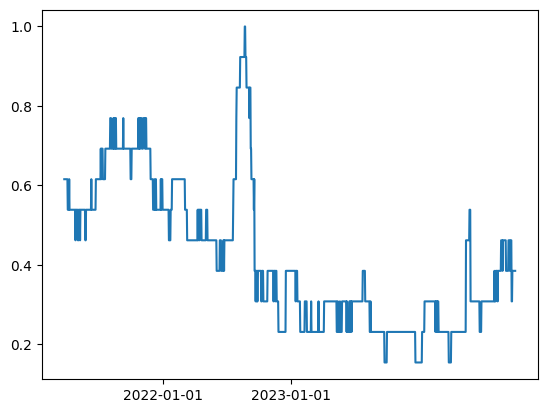

In [6]:
plt.plot(langs["val_noexp", "cpp"])
plt.xticks(['2022-01-01', '2023-01-01'])

In [7]:
def graphs(column, window):
    colmns = langs[column].columns

    langs1 = langs[column].copy()
    langs2 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        langs2[i] = langs2[i].rolling(window=window).mean()
        langs2[i] = langs2[i].shift(window)

        if col[:2] != 'Py':
            ax.plot(langs1[i] - langs2[i])
            labels.append(langs2[i].name)
            col = i
        else:
            ax.plot(langs1[i] - langs2[i], linestyle='--')
            labels.append(langs2[i].name)
            col = 'Py'

    ax.legend(labels, loc='upper left')
    ax.axhline(y=0, color='k')
    plt.xticks('')
    #ax.set_xticklabels((date), rotation=90)

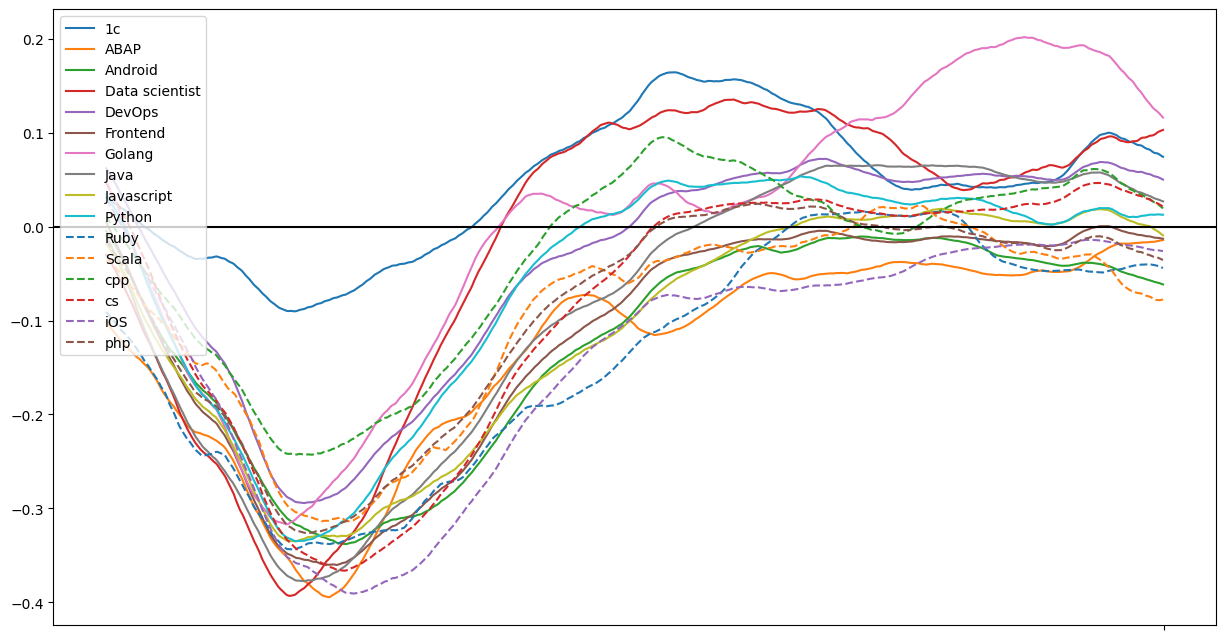

In [8]:
graphs('val', 200)

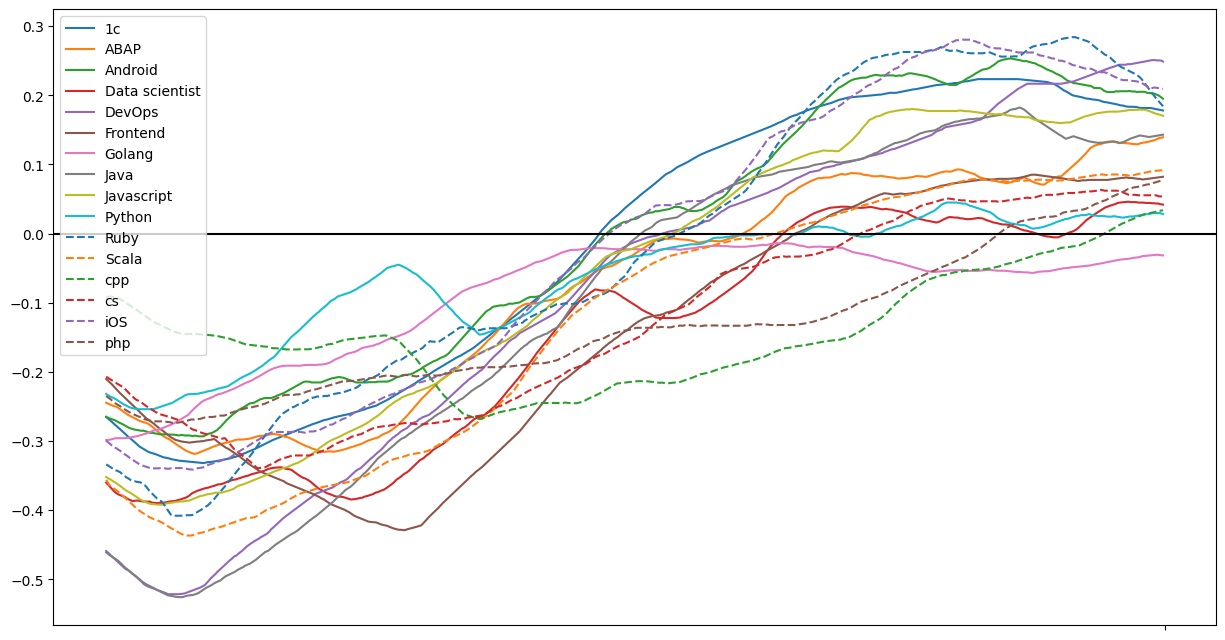

In [9]:
graphs('val_noexp', 300)

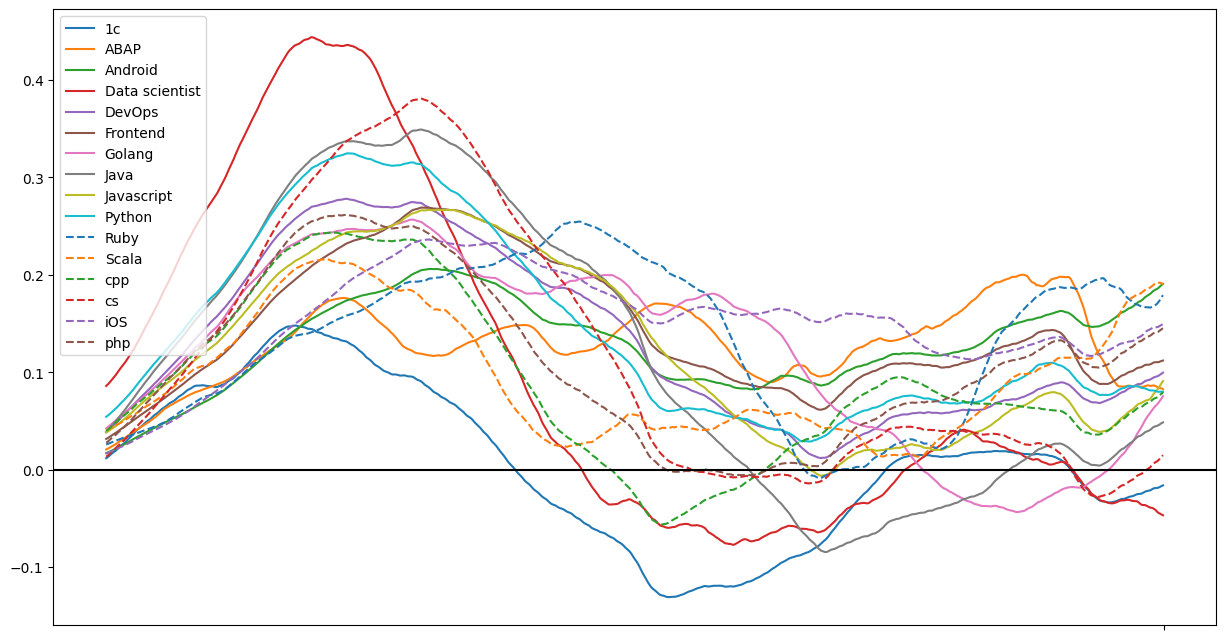

In [10]:
graphs('res_vac', 200)

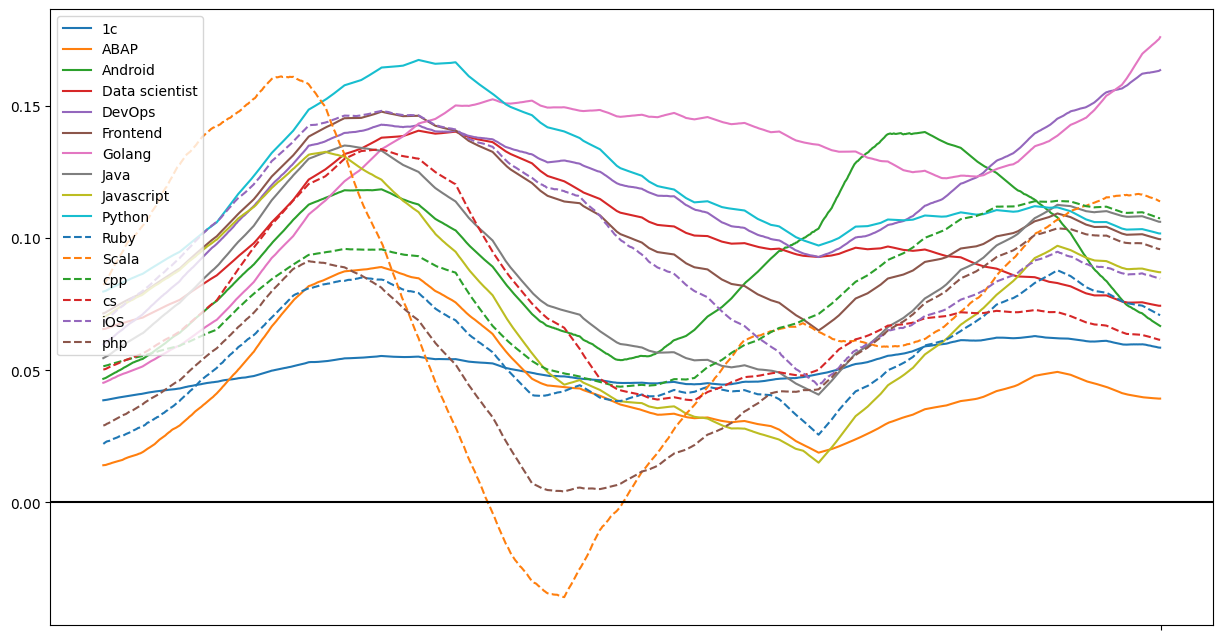

In [11]:
graphs('res', 200)

In [12]:
langs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1285 entries, 2021-03-26 to 2024-10-02
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   (val, 1c)                    1285 non-null   float64
 1   (val, ABAP)                  1285 non-null   float64
 2   (val, Android)               1285 non-null   float64
 3   (val, Data scientist)        1285 non-null   float64
 4   (val, DevOps)                1285 non-null   float64
 5   (val, Frontend)              1285 non-null   float64
 6   (val, Golang)                1285 non-null   float64
 7   (val, Java)                  1285 non-null   float64
 8   (val, Javascript)            1285 non-null   float64
 9   (val, Python)                1285 non-null   float64
 10  (val, Ruby)                  1285 non-null   float64
 11  (val, Scala)                 1285 non-null   float64
 12  (val, cpp)                   1285 non-null   float64
 13  (val, cs

In [13]:
import seaborn as sns

def corr(colmns):
    plt.figure(figsize=(10,10))
    sns.set(font_scale=1.0)
    sns.heatmap(pd.DataFrame(langs[colmns]).corr(),cmap='GnBu',annot=True)

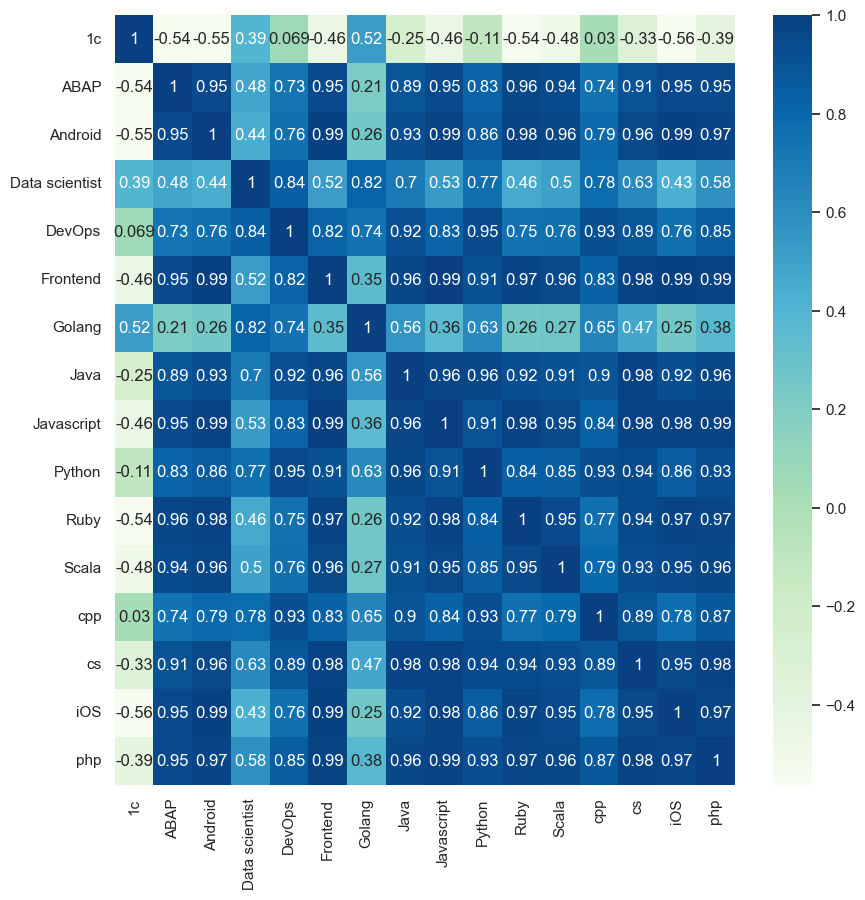

In [14]:
corr('val')

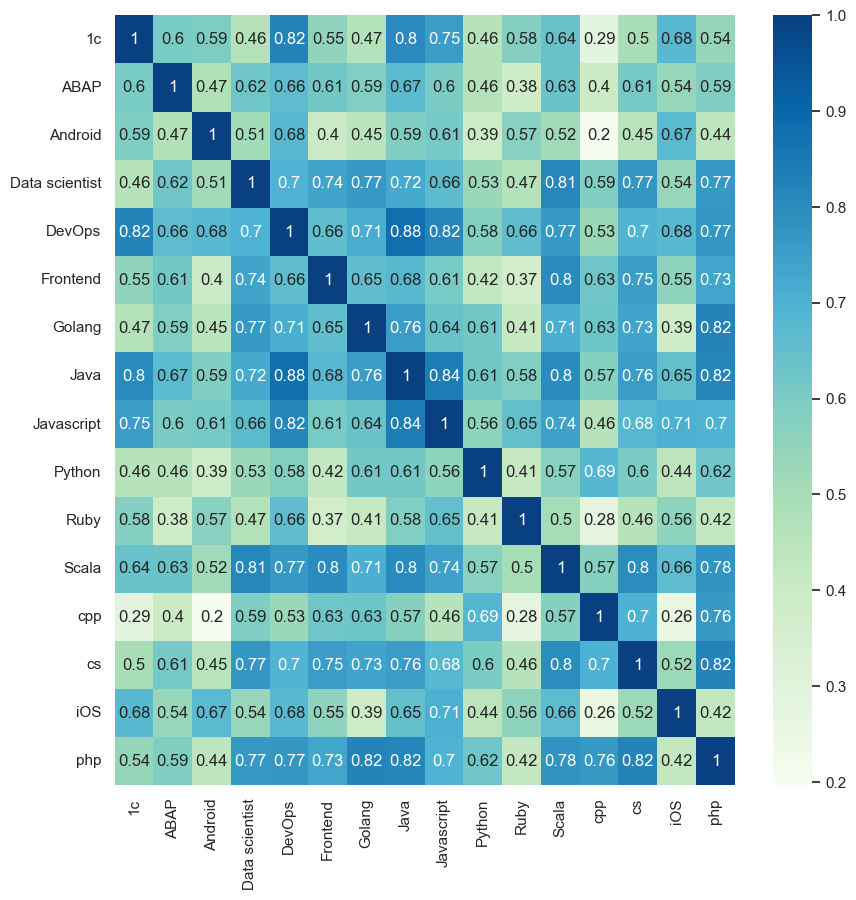

In [15]:
corr('val_noexp')

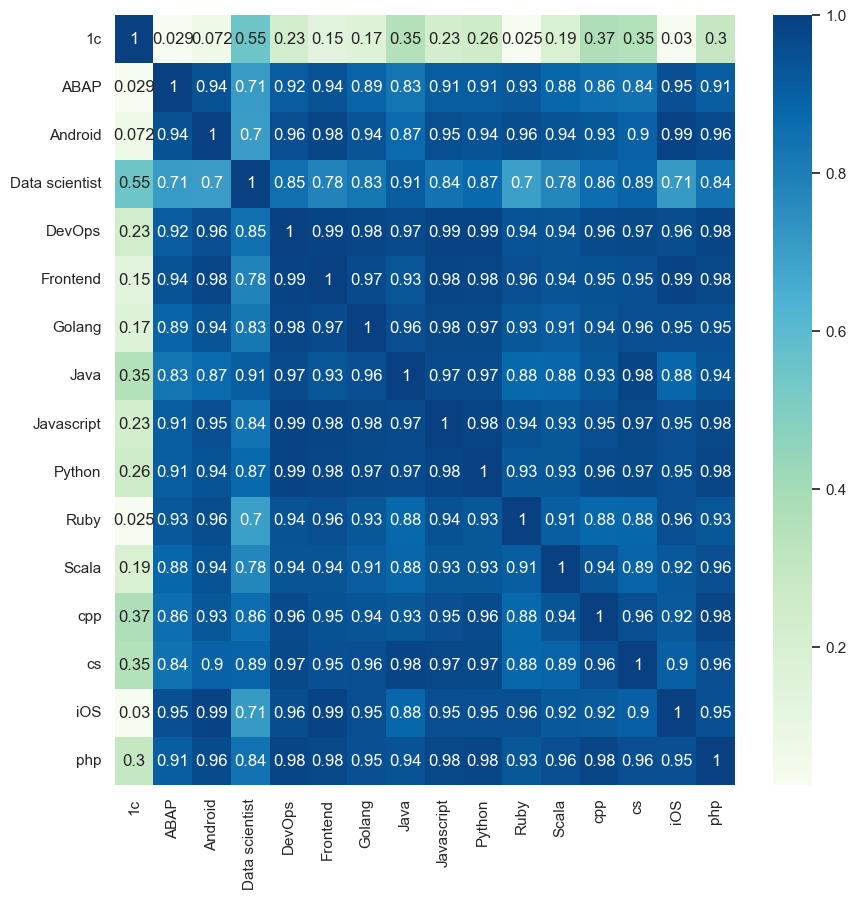

In [16]:
corr('res_vac')

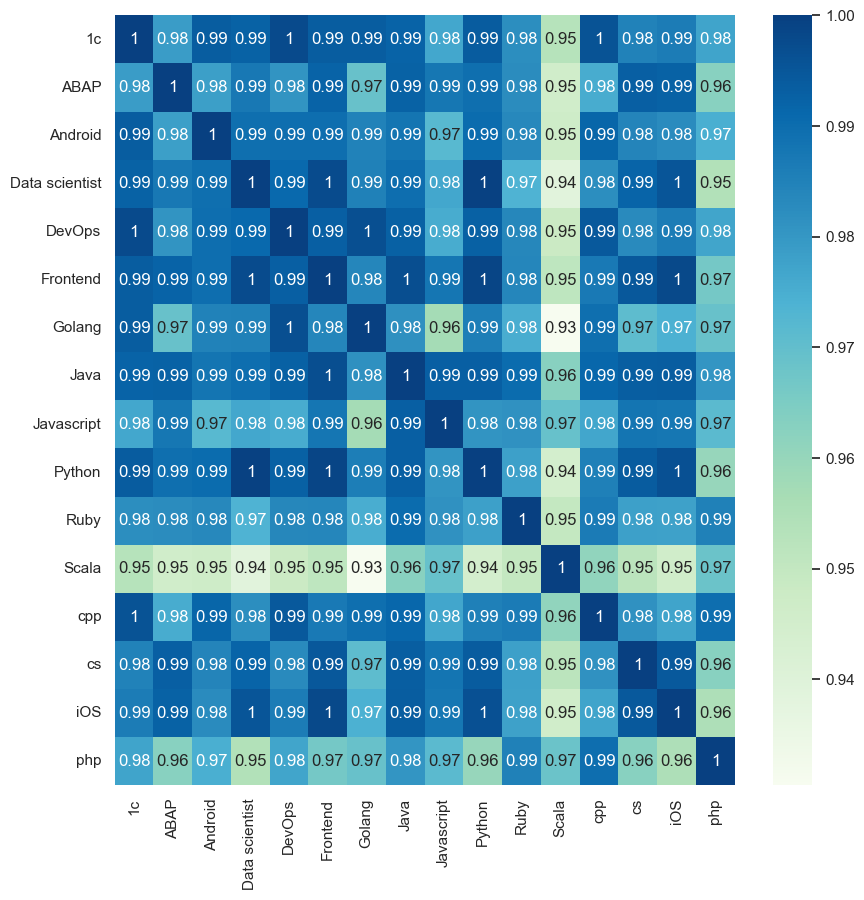

In [17]:
corr('res')

In [18]:
langs.index = pd.to_datetime(langs.index)

def year(x):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    plt.plot(langs[x].groupby(langs.index.strftime('%m-%d')).median().median(axis=1))
    plt.xticks([str(i).zfill(2) + "-01" for i in range(1, 13)])
    plt.grid()

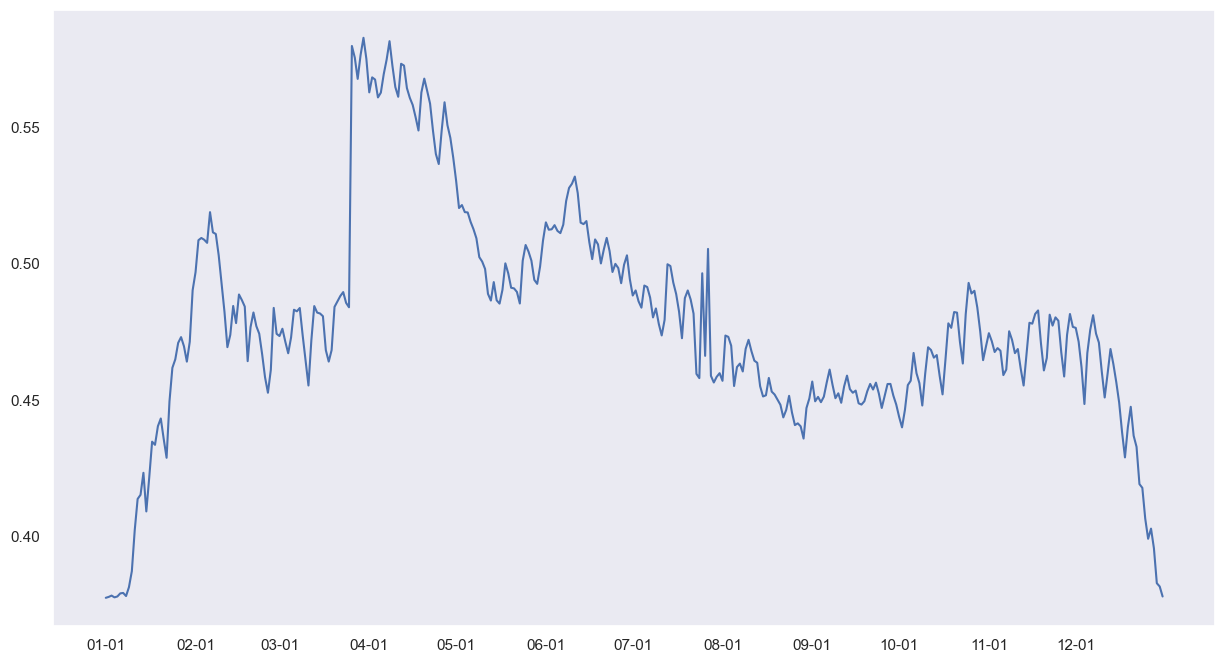

In [19]:
year("val")

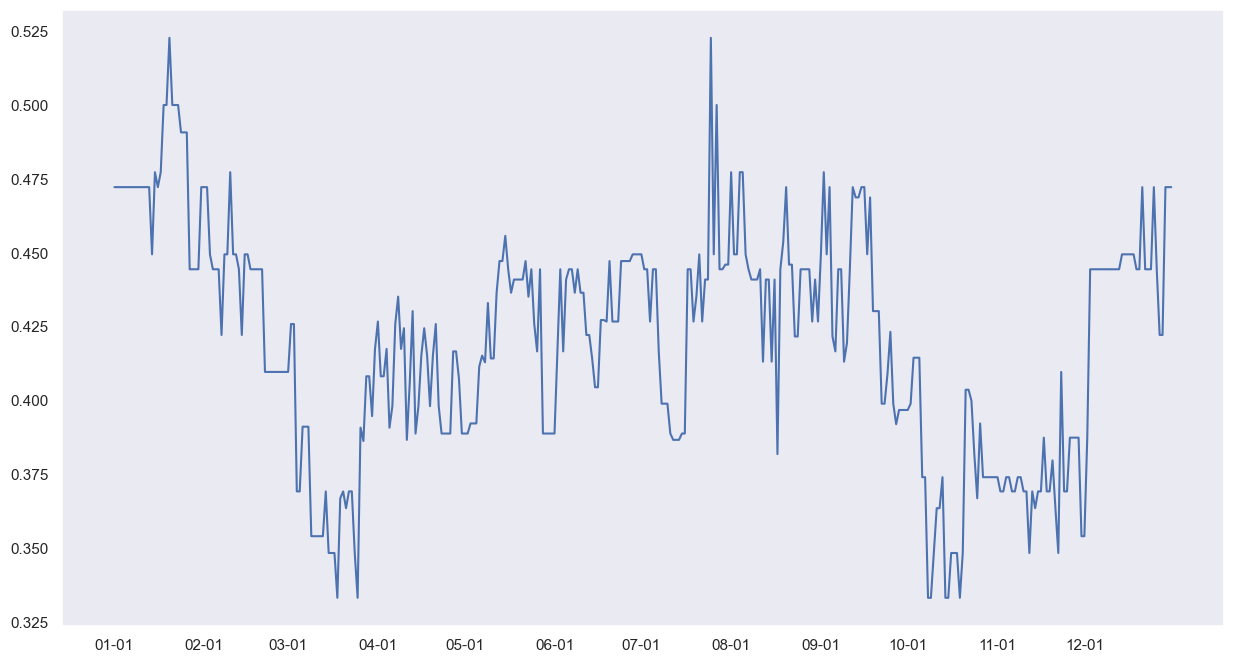

In [20]:
year("val_noexp")

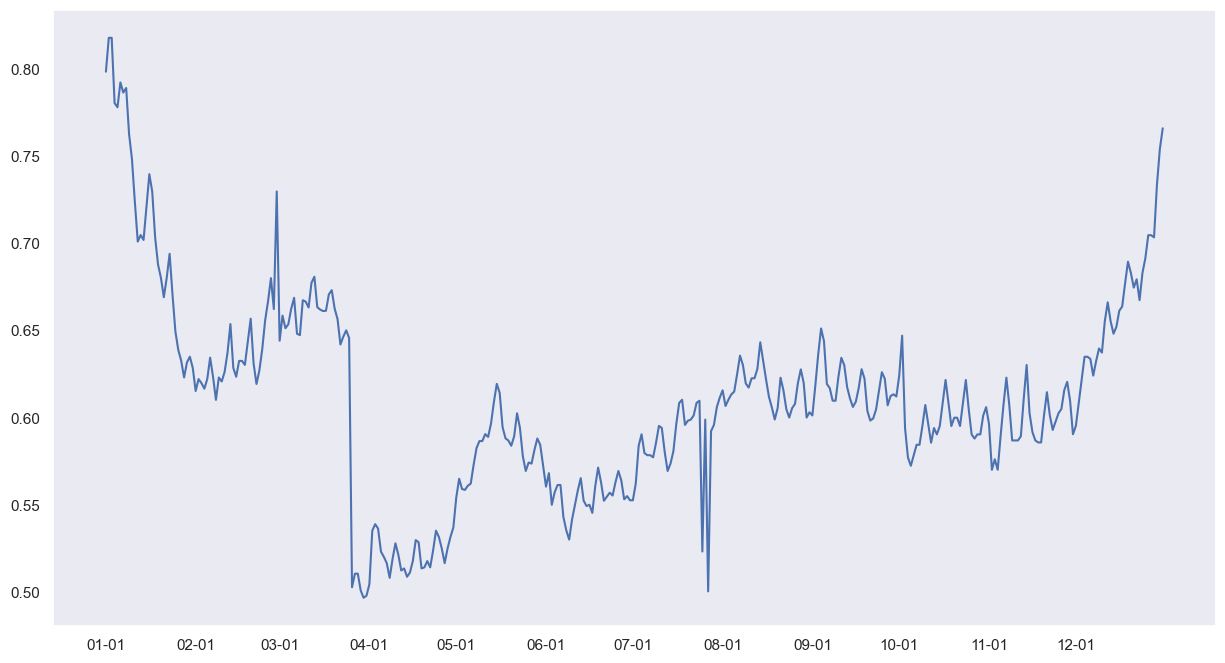

In [21]:
year("res_vac")

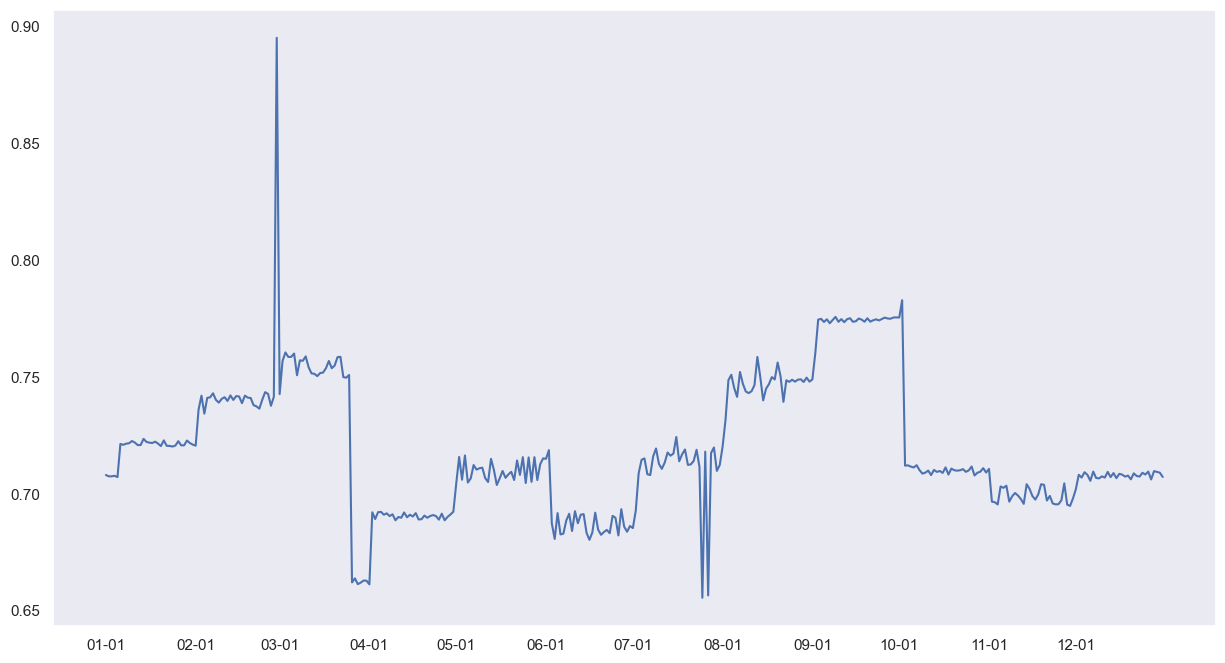

In [22]:
year("res")

In [23]:
def graphs(column, window):
    colmns = langs[column].columns
    langs1 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        
        if col[:2] != 'Py':
            ax.plot(langs1[i])
            labels.append(langs1[i].name)
            col = i
        else:
            ax.plot(langs1[i], linestyle='--')
            labels.append(langs1[i].name)
            col = 'Py'

    ax.legend(labels)
    #plt.xticks('')

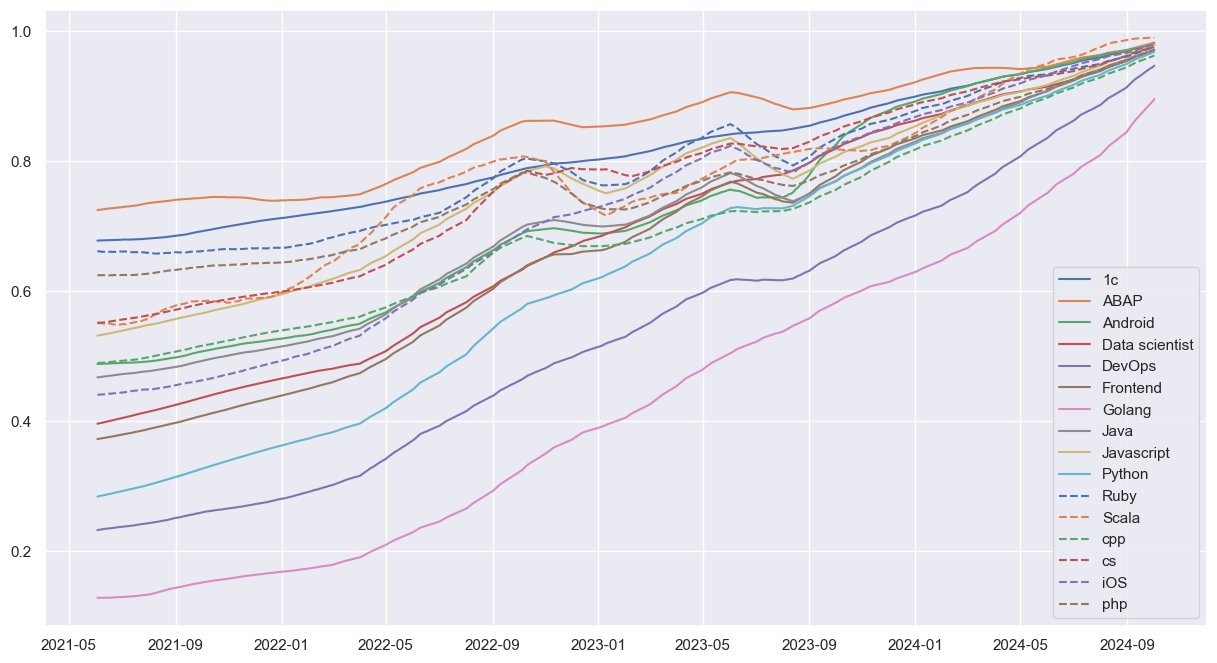

In [24]:
graphs("res", 70)